In [ ]:

# RevNet reversible block example
class RevBlock(nn.Module):
    def __init__(self, channels):
        super(RevBlock, self).__init__()
        self.F = nn.Sequential(
            nn.Conv2d(channels // 2, channels // 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels // 2, channels // 2, kernel_size=3, padding=1),
        )
        self.G = nn.Sequential(
            nn.Conv2d(channels // 2, channels // 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels // 2, channels // 2, kernel_size=3, padding=1),
        )

    def forward(self, x):
        x1, x2 = torch.chunk(x, 2, dim=1)
        y1 = x1 + self.F(x2)
        y2 = x2 + self.G(y1)
        y = torch.cat([y1, y2], dim=1)
        return y

    def inverse(self, y):
        y1, y2 = torch.chunk(y, 2, dim=1)
        x2 = y2 - self.G(y1)
        x1 = y1 - self.F(x2)
        x = torch.cat([x1, x2], dim=1)
        return x

# RevNet model with multiple reversible blocks
class RevNet(nn.Module):
    def __init__(self, channels=6):  # 3 for image + 3 for watermark matrix (example)
        super(RevNet, self).__init__()
        self.revblock1 = RevBlock(channels)
        self.revblock2 = RevBlock(channels)

    def forward(self, x):
        x = self.revblock1(x)
        x = self.revblock2(x)
        return x 

    def inverse(self, y):
        y = self.revblock2.inverse(y)
        y = self.revblock1.inverse(y)
        return y


In [8]:
!pip install hilbertcurve

---------------------------------------------------------------------------------------------------------------------
## FOR REAL THIS TIME

In [1]:
# first import stuff
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader, Dataset
import os
import random
from PIL import Image

In [2]:
# CONFIG
order = 6       # Hilbert curve order (for 8x8 block, order=3) since we are converting images to 64x64 we are taking order as 6
dimensions = 2  # 2D
batch_size = 16

In [3]:
# now we need our hilbert curve - aka watermark
from hilbertcurve.hilbertcurve import HilbertCurve
import numpy as np

# Parameters
def generate_hilbert_curve(order, dimensions):
    N = 2 ** order
    hilbert_curve = HilbertCurve(order, dimensions)
    num_points = N * N
    hilbert_indices = [hilbert_curve.point_from_distance(i) for i in range(num_points)]
    #print(hilbert_indices)
    return hilbert_indices

hilbert_indices = generate_hilbert_curve(order, dimensions)


In [4]:
def convert_indices_to_int(order):

    """
    Converts a 2D coordinate (x, y) to its Hilbert curve distance 'd'.
    This is a self-contained implementation of the algorithm.

    Args:
        x (int): The x-coordinate.
        y (int): The y-coordinate.
        order (int): The order of the Hilbert curve.

    Returns:
        int: The Hilbert curve distance (index).
    """
    # apparently generating indices doesnt need the [x, y] coordinates generated in the prev cell. lol
    side_length = 2**order
    hilbert_matrix = np.zeros((side_length, side_length), dtype=int)
    
    def xy_to_d(x,y,order):
        d = 0
        # Iterate through each level of the curve's order
        for s_val in range(order - 1, -1, -1):
            side_len_sub_quad = 2**s_val
            # Determine the quadrant for the current level
            rx = (x >> s_val) & 1
            ry = (y >> s_val) & 1

            # Add the contribution of the quadrant to the total distance
            d += side_len_sub_quad * side_len_sub_quad * ((3 * rx) ^ ry)

            # Rotate/transform the coordinates for the next iteration
            if ry == 0:
                if rx == 1:
                    x = side_len_sub_quad - 1 - x
                    y = side_len_sub_quad - 1 - y
                x, y = y, x

        return d

        # Iterate through each coordinate (x, y) in the grid
    for y in range(side_length):
        for x in range(side_length):
            # Calculate the Hilbert index for the coordinate (x, y)
            distance = xy_to_d(x, y, order)
            # Assign this index to the matrix at the correct cell
            hilbert_matrix[y, x] = distance
    return hilbert_matrix

print(convert_indices_to_int(order))


[[   0    1   14 ... 4081 4094 4095]
 [   3    2   13 ... 4082 4093 4092]
 [   4    7    8 ... 4087 4088 4091]
 ...
 [1363 1362 1373 ... 2722 2733 2732]
 [1364 1367 1368 ... 2727 2728 2731]
 [1365 1366 1369 ... 2726 2729 2730]]


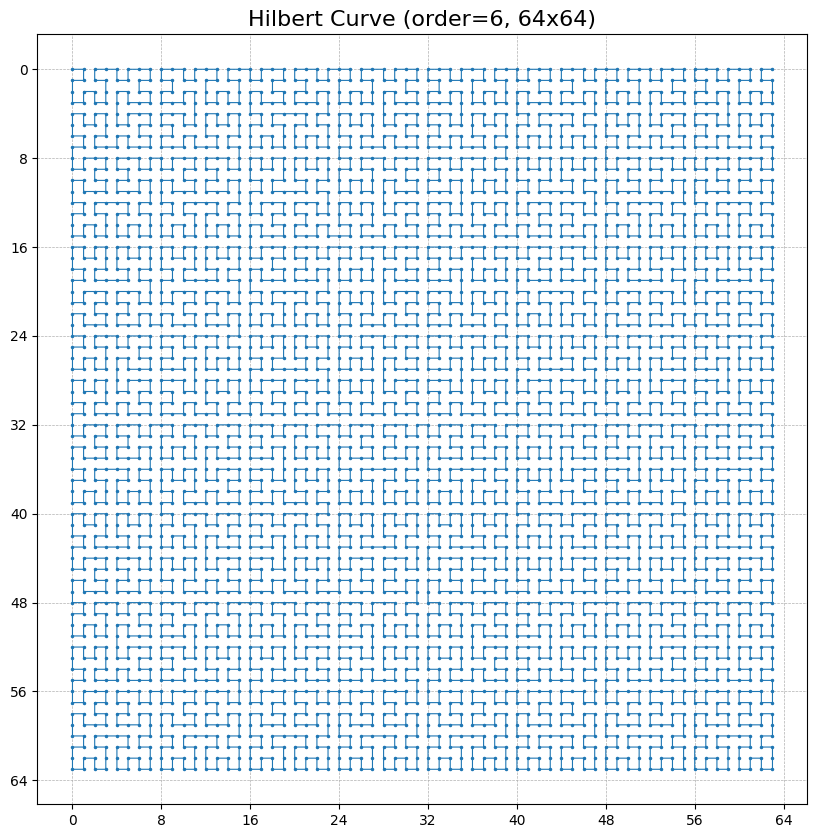

In [5]:
# now lets try to plot the hilbert curve
import matplotlib.pyplot as plt

def plot_hilbert_curve(hilbert_indices, order):
    N = 2**order
    x_coords = [p[0] for p in hilbert_indices]
    y_coords = [p[1] for p in hilbert_indices]

    # 4. Create the visualization
    plt.figure(figsize=(10, 10))  # Use a larger figure for better detail

    # Plot the curve with smaller markers and a thinner line
    # The text labels are removed to keep the plot clean
    plt.plot(x_coords, y_coords, marker='o', markersize=1.5, linewidth=0.8)

    # Set title and ensure the aspect ratio is correct
    plt.title(f'Hilbert Curve (order={order}, {N}x{N})', fontsize=16)
    plt.gca().set_aspect('equal', adjustable='box')

    # Invert the y-axis to match the example image (0,0 at top-left)
    plt.gca().invert_yaxis()
    plt.grid(True, linestyle='--', linewidth=0.5)

    # Set explicit ticks to prevent the axis labels from becoming too crowded
    ticks = range(0, N + 1, 8)
    plt.xticks(ticks)
    plt.yticks(ticks)

    plt.show()
    
plot_hilbert_curve(hilbert_indices=hilbert_indices, order=order)

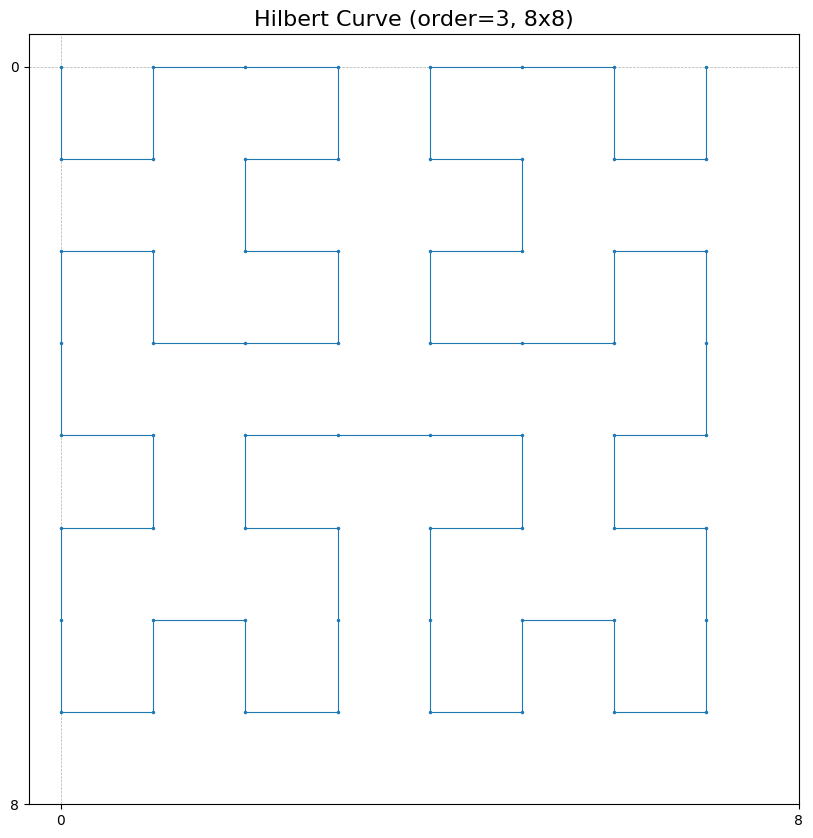

In [6]:
# since the above is too kocha-kocha lets try 4x4
hilbert_indices_3 = generate_hilbert_curve(order=3, dimensions=2)
plot_hilbert_curve(hilbert_indices=hilbert_indices_3, order=3)

In [7]:
# okay now lets generate 3 hilbert curves for each image (because no reason) so that the image may become  lxwx6
import math
# Space-filling curve watermark generator placeholder
def generate_watermark_matrix(batch_size, side):
    hilbert_matrix = convert_indices_to_int(int(math.log2(side)))
    #print(hilbert_matrix)

    # Normalize to [0, 1]
    hilbert_norm = hilbert_matrix.astype(np.float32) / (64*64 - 1)
    
    hilbert_tensor = torch.tensor(hilbert_norm).unsqueeze(0).repeat(batch_size, 1, 1, 1)  # shape: [batch, 1, 64, 64]
    # If you want 3 channels (like RGB)
    hilbert_tensor_3c = hilbert_tensor.repeat(1, 3, 1, 1)  # shape: [batch, 3, 64, 64]
    return hilbert_tensor_3c

h_tensor = generate_watermark_matrix(1, 8)

In [8]:
h_tensor

tensor([[[[0.0000, 0.0007, 0.0010, 0.0012, 0.0142, 0.0144, 0.0147, 0.0154],
          [0.0002, 0.0005, 0.0017, 0.0015, 0.0139, 0.0137, 0.0149, 0.0151],
          [0.0034, 0.0032, 0.0020, 0.0022, 0.0132, 0.0134, 0.0122, 0.0120],
          [0.0037, 0.0029, 0.0027, 0.0024, 0.0129, 0.0127, 0.0125, 0.0117],
          [0.0039, 0.0042, 0.0073, 0.0076, 0.0078, 0.0081, 0.0112, 0.0115],
          [0.0046, 0.0044, 0.0071, 0.0068, 0.0085, 0.0083, 0.0110, 0.0107],
          [0.0049, 0.0056, 0.0059, 0.0066, 0.0088, 0.0095, 0.0098, 0.0105],
          [0.0051, 0.0054, 0.0061, 0.0063, 0.0090, 0.0093, 0.0100, 0.0103]],

         [[0.0000, 0.0007, 0.0010, 0.0012, 0.0142, 0.0144, 0.0147, 0.0154],
          [0.0002, 0.0005, 0.0017, 0.0015, 0.0139, 0.0137, 0.0149, 0.0151],
          [0.0034, 0.0032, 0.0020, 0.0022, 0.0132, 0.0134, 0.0122, 0.0120],
          [0.0037, 0.0029, 0.0027, 0.0024, 0.0129, 0.0127, 0.0125, 0.0117],
          [0.0039, 0.0042, 0.0073, 0.0076, 0.0078, 0.0081, 0.0112, 0.0115],
          

In [9]:
# now lets prep our dataset
# Custom dataset class
class CelebADataset(Dataset):
    def __init__(self, img_dir, image_files, transform=None):
        self.img_dir = img_dir
        self.image_files = image_files
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image


In [10]:
# Set image directory
image_directory = 'celebA/img_align_celeba/img_align_celeba'

# List and shuffle images
all_images = [f for f in os.listdir(image_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random.seed(42)
random.shuffle(all_images)

# Split into train/val/test sets (80/10/10 split)
num_total = 400 #len(all_images)
num_train = 250 #int(0.8 * num_total)
num_val = 75 #int(0.1 * num_total)
num_test = 75 #num_total - num_train - num_val

train_images = all_images[:num_train]
val_images = all_images[num_train:num_train+num_val]
test_images = all_images[num_train+num_val:]

# Transforms
transform = transforms.Compose([# so the transforms we are applying are basically preprocessing steps
    transforms.Resize((64, 64)), #this is resize (lol)
    transforms.ToTensor(), # this is to convert each img to tensor
])

# Datasets
train_dataset = CelebADataset(img_dir=image_directory, image_files=train_images, transform=transform)
val_dataset = CelebADataset(img_dir=image_directory, image_files=val_images, transform=transform)
test_dataset = CelebADataset(img_dir=image_directory, image_files=test_images, transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


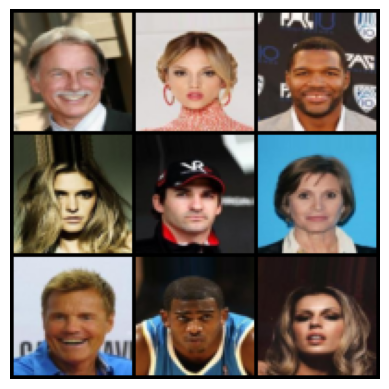

In [11]:
# let's display the first few imgs
# 1. Get one batch of training images
data_iter = iter(train_loader)
images = next(data_iter)

# 2. Create a grid of images
# We select the first 9 images from the batch and arrange them in a 3x3 grid.
img_grid = utils.make_grid(images[:9], nrow=3)

# 3. Prepare the grid for display
np_img_grid = img_grid.numpy()
plt.imshow(np.transpose(np_img_grid, (1, 2, 0))) # the reason we do transpose is because tensors are stored as (channels, height, width) in pytorch but plt needs (height, width, channels)

# 4. Display the grid
plt.axis('off') # Hide the axes for a cleaner look
plt.show()

the images are 64x64 so.... THEY BE BLURRY

In [ ]:
# now. OUR MODEL

# RevNet reversible block example
class RevBlock(nn.Module):
    def __init__(self, channels):
        super(RevBlock, self).__init__()
        self.F = nn.Sequential(
            nn.Conv2d(channels // 2, channels // 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels // 2, channels // 2, kernel_size=3, padding=1),
        )
        self.G = nn.Sequential(
            nn.Conv2d(channels // 2, channels // 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels // 2, channels // 2, kernel_size=3, padding=1),
        )

    def forward(self, x):
        x1, x2 = torch.chunk(x, 2, dim=1)
        y1 = x1 + self.F(x2)
        y2 = x2 + self.G(y1)
        y = torch.cat([y1, y2], dim=1)
        return y

    def inverse(self, y):
        y1, y2 = torch.chunk(y, 2, dim=1)
        x2 = y2 - self.G(y1)
        x1 = y1 - self.F(x2)
        x = torch.cat([x1, x2], dim=1)
        return x


class RevNet(nn.Module):
    def __init__(self, channels=6):  # 3 for image + 3 for watermark matrix
        super(RevNet, self).__init__()
        self.revblock1 = RevBlock(channels)
        self.revblock2 = RevBlock(channels)

    def forward(self, x):
        x = self.revblock1(x)
        x = self.revblock2(x)
        return x 

    def inverse(self, y):
        y = self.revblock2.inverse(y)
        y = self.revblock1.inverse(y)
        return y
 

In [15]:
from torchvision.transforms import ToTensor, ToPILImage
import random
from PIL import Image
import io

# Helper Function 1: Gaussian Noise
def apply_gaussian_noise(images, std=0.075):
    """Adds Gaussian noise to a batch of images."""
    # Ensure the input is a floating-point tensor for noise addition
    images = images.float()
    
    # Generate noise with the same shape as the images
    noise = torch.randn_like(images) * std
    
    # Add noise and clamp the result to the valid [0, 1] range
    noisy_images = images + noise
    #print(1)
    return torch.clamp(noisy_images, 0.0, 1.0)


# Helper Function 2: Simulated JPEG Compression
def apply_jpeg_compression(images):
    """Simulates JPEG compression for a batch of images."""
    # This process is computationally more intensive as it requires a loop
    images = images.cpu()
    compressed_images = []
    
    # Initialize converters
    to_pil = ToPILImage()
    to_tensor = ToTensor()
    
    for img_tensor in images:
        # Convert tensor to PIL Image
        pil_img = to_pil(img_tensor)
        
        # Save to an in-memory buffer with random JPEG quality
        buffer = io.BytesIO()
        quality = random.randint(50, 95) # Random quality between 50 and 95
        pil_img.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        
        # Read back from buffer and convert to tensor
        img_compressed_pil = Image.open(buffer)
        img_compressed_tensor = to_tensor(img_compressed_pil)
        compressed_images.append(img_compressed_tensor)
        
    # Stack the list of tensors back into a single batch tensor
    #print(2)
    return torch.stack(compressed_images).to(images.device)

# Helper Function 3: Sharpening Filter
def apply_sharpening(images):
    """Applies a sharpening kernel to a batch of images."""
    num_channels = images.size(1)
    
    # Define a classic 3x3 sharpening kernel
    kernel_base = torch.tensor([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=torch.float32)
    
    # Reshape kernel to be (out_channels, in_channels/groups, H, W)
    # We create a depthwise convolution kernel where each channel gets its own filter
    kernel = kernel_base.view(1, 1, 3, 3).repeat(num_channels, 1, 1, 1)
    
    # Move kernel to the same device as the images
    kernel = kernel.to(images.device)
    
    # Create a convolution layer on the fly
    # 'groups=num_channels' makes it a depthwise convolution
    # 'padding=1' keeps the image size constant
    conv = nn.Conv2d(in_channels=num_channels, out_channels=num_channels, kernel_size=3, 
                     groups=num_channels, padding=1, bias=False)
    
    # Set the layer's weight to be our sharpening kernel
    conv.weight = nn.Parameter(kernel, requires_grad=False)
    
    # Apply the convolution and clamp the output
    sharpened_images = conv(images)
    #print(3)
    return torch.clamp(sharpened_images, 0.0, 1.0)


# --- Main Function ---
def apply_corruptions(images):
    """
    Randomly applies one of three corruptions to a batch of images:
    Gaussian noise, JPEG compression, or sharpening.
    
    Args:
        images (torch.Tensor): A batch of images with shape [B, C, H, W]
                               and pixel values in the [0, 1] range.
                               
    Returns:
        torch.Tensor: The batch of corrupted images.
    """
    corruption_funcs = [
        apply_gaussian_noise,
        apply_jpeg_compression,
        apply_sharpening
    ]
    
    # Randomly choose one corruption function from the list
    chosen_corruption = random.choice(corruption_funcs)
    
    # Apply the chosen corruption and return the result
    return chosen_corruption(images)

3


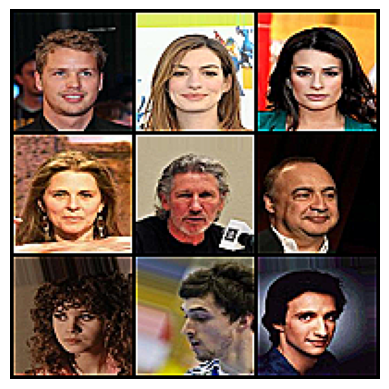

In [14]:
# lets try out diff corruption stuff
data_iter = iter(train_loader)
images = next(data_iter)

temp = images.clone()

to_corr = temp[:9]
corred = apply_corruptions(to_corr)
# 2. Create a grid of images
# We select the first 9 images from the batch and arrange them in a 3x3 grid.

img_grid = utils.make_grid(corred, nrow=3)

# 3. Prepare the grid for display
np_img_grid = img_grid.numpy()
plt.imshow(np.transpose(np_img_grid, (1, 2, 0))) # the reason we do transpose is because tensors are stored as (channels, height, width) in pytorch but plt needs (height, width, channels)

# 4. Display the grid
plt.axis('off') # Hide the axes for a cleaner look
plt.show()

In [ ]:
# Initialize model, optimizer, loss function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RevNet(channels=6).to(device)  # 3 image + 3 watermark channels
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()
# Loss weights (hyperparameters you can tune)
w_imperceptibility = 1.0
w_extraction = 1.0

# Training loop skeleton
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    for batch_idx, images in enumerate(train_loader):
        images = images.to(device)
        # Generate watermark matrix with same spatial size as images
        # print(images.size(0), images.size(1), images.size(2), images.size(3))
        
        watermarks = generate_watermark_matrix(images.size(0), images.size(2)).to(device) #assuming that the length and width are same
        
        # Concatenate image and watermark matrix channels
        input_tensor = torch.cat([images, watermarks], dim=1)

        # Forward pass: embed watermark (example representation)
        embedded = model(input_tensor)
        embedded_image, embedded_watermark_part = torch.chunk(embedded, 2, dim=1)
        loss_imperceptibility = criterion(embedded_image, images)

        # --- CORRUPTION & EXTRACTION LOSS ---
        corrupted_image = apply_corruptions(embedded_image)
        # We detach the watermark part to prevent gradients from flowing back in a confusing loop
        corrupted_input_for_inverse = torch.cat([corrupted_image, embedded_watermark_part.detach()], dim=1)
        
        recovered = model.inverse(corrupted_input_for_inverse)
        _, recovered_watermark = torch.chunk(recovered, 2, dim=1)
        loss_extraction = criterion(recovered_watermark, watermarks)
        
        # --- TOTAL LOSS ---
        loss = (w_imperceptibility * loss_imperceptibility) + (w_extraction * loss_extraction)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Total Loss: {loss.item():.6f}")
        if batch_idx % 100 == 0:
            print(f"    Imperceptibility: {loss_imperceptibility.item():.6f}, Extraction: {loss_extraction.item():.6f}")

print("Training complete.")


Epoch [1/5], Step [1/16], Total Loss: 0.041805
    Imperceptibility: 0.041150, Extraction: 0.000654
Epoch [1/5], Step [2/16], Total Loss: 0.041496
Epoch [1/5], Step [3/16], Total Loss: 0.041231
Epoch [1/5], Step [4/16], Total Loss: 0.040559
Epoch [1/5], Step [5/16], Total Loss: 0.045980
Epoch [1/5], Step [6/16], Total Loss: 0.046321
Epoch [1/5], Step [7/16], Total Loss: 0.044675
Epoch [1/5], Step [8/16], Total Loss: 0.039656
Epoch [1/5], Step [9/16], Total Loss: 0.045592
Epoch [1/5], Step [10/16], Total Loss: 0.043736
Epoch [1/5], Step [11/16], Total Loss: 0.038306
Epoch [1/5], Step [12/16], Total Loss: 0.037972
Epoch [1/5], Step [13/16], Total Loss: 0.037680
Epoch [1/5], Step [14/16], Total Loss: 0.042051
Epoch [1/5], Step [15/16], Total Loss: 0.037472
Epoch [1/5], Step [16/16], Total Loss: 0.036976
Epoch [2/5], Step [1/16], Total Loss: 0.036425
    Imperceptibility: 0.036039, Extraction: 0.000386
Epoch [2/5], Step [2/16], Total Loss: 0.036403
Epoch [2/5], Step [3/16], Total Loss: 0.0

In [18]:
!pip install torchmetrics

   ---------------------------------------- 0.0/983.0 kB ? eta -:--:--
   --------------------- ------------------ 524.3/983.0 kB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 983.0/983.0 kB 2.9 MB/s  0:00:00

   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   ------------

In [25]:
# validation be like
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

def evaluate_model(model, val_loader, device, criterion):
    """
    Evaluates the RevNet model on the validation set.

    Args:
        model (nn.Module): The trained RevNet model.
        val_loader (DataLoader): The DataLoader for the validation set.
        device (torch.device): The device to run on (e.g., 'cuda' or 'cpu').
        criterion (nn.Module): The loss function (e.g., MSELoss) for watermark comparison.
    """
    # Set the model to evaluation mode
    model.eval()

    # Initialize metric calculators
    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    
    # Running totals for the epoch
    total_psnr = 0.0
    total_ssim = 0.0
    total_watermark_mse = 0.0

    # Disable gradient calculations for efficiency
    with torch.no_grad():
        for batch_idx, images in enumerate(val_loader):
            images = images.to(device)
            # Generate the same watermarks used during training
            watermarks = generate_watermark_matrix(images.size(0), images.size(2)).to(device)
            
            input_tensor = torch.cat([images, watermarks], dim=1)

            # --- 1. Imperceptibility Check (Forward Pass) ---
            embedded = model(input_tensor)
            embedded_image, embedded_watermark_part = torch.chunk(embedded, 2, dim=1)
            
            # Update PSNR and SSIM totals
            cur_psnr = psnr_metric(embedded_image, images)
            cur_ssim = ssim_metric(embedded_image, images)
            total_psnr += cur_psnr
            total_ssim += cur_ssim

            # --- 2. Robustness Check (Corruption + Inverse Pass) ---
            corrupted_image = apply_corruptions(embedded_image)
            corrupted_input_for_inverse = torch.cat([corrupted_image, embedded_watermark_part], dim=1)
            
            recovered = model.inverse(corrupted_input_for_inverse)
            _, recovered_watermark = torch.chunk(recovered, 2, dim=1)

            # Calculate and update watermark recovery MSE
            watermark_mse = criterion(recovered_watermark, watermarks)
            total_watermark_mse += watermark_mse.item()
            
            print(f"Step [{batch_idx+1}] Embedding -> PSNR: {cur_psnr} | SSIM: {cur_ssim} | Extraction -> Watermark MSE: {watermark_mse}")

    # Calculate average metrics for the entire validation set
    avg_psnr = total_psnr / len(val_loader)
    avg_ssim = total_ssim / len(val_loader)
    avg_watermark_mse = total_watermark_mse / len(val_loader)

    print("\n--- Validation Results ---")
    print(f"Average PSNR: {avg_psnr:.4f} dB")
    print(f"Average SSIM: {avg_ssim:.4f}")
    print(f"Average Watermark MSE: {avg_watermark_mse:.6f}")
    print("--------------------------\n")

    return avg_psnr, avg_ssim, avg_watermark_mse

In [26]:
evaluate_model(model=model, device=device, val_loader=val_loader, criterion=criterion)

Step [1] Embedding -> PSNR: 16.69031524658203 | SSIM: 0.727809727191925 | Extraction -> Watermark MSE: 0.0006280886009335518
Step [2] Embedding -> PSNR: 16.688505172729492 | SSIM: 0.7730064392089844 | Extraction -> Watermark MSE: 0.0025291487108916044
Step [3] Embedding -> PSNR: 16.68902015686035 | SSIM: 0.7765588760375977 | Extraction -> Watermark MSE: 0.003258743090555072
Step [4] Embedding -> PSNR: 16.690662384033203 | SSIM: 0.750975489616394 | Extraction -> Watermark MSE: 0.0006543734925799072
Step [5] Embedding -> PSNR: 16.687646865844727 | SSIM: 0.7316970825195312 | Extraction -> Watermark MSE: 0.004231588914990425

--- Validation Results ---
Average PSNR: 16.6892 dB
Average SSIM: 0.7520
Average Watermark MSE: 0.002260
--------------------------



(tensor(16.6892), tensor(0.7520), 0.002260388561990112)

### results: 

The model is able to extract watermark well but it is losing out on imperceptibility. It's giving up PSNR and SSIM for watermark MSE. sadge

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3233117..1.2050213].


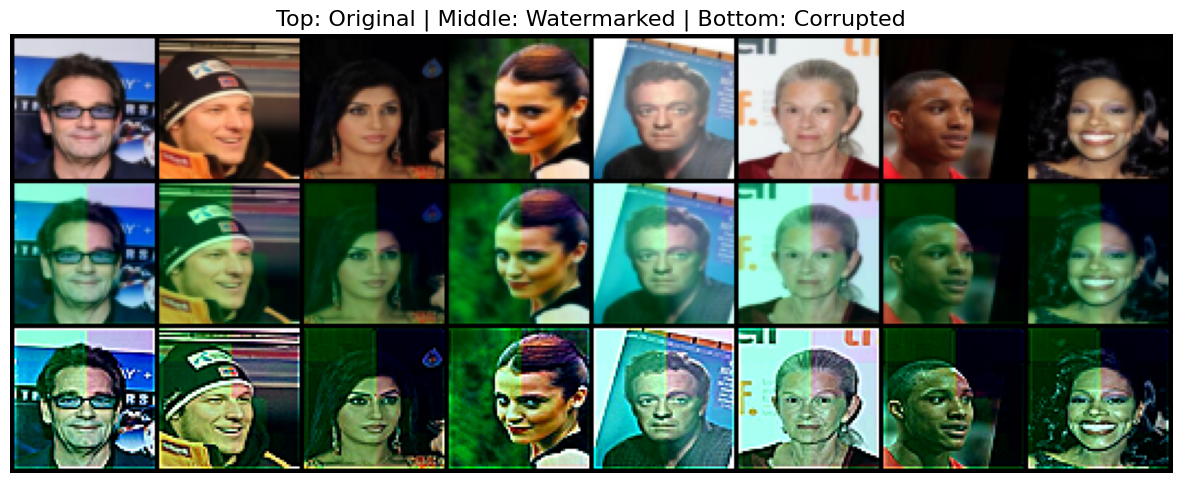

In [28]:
import torch
import torchvision.utils as utils
import matplotlib.pyplot as plt
import numpy as np

def show_watermarking_results(model, loader, device, num_images=8):
    """
    Visualizes the output of the watermarking process on a batch of images.

    Args:
        model (nn.Module): The trained RevNet model.
        loader (DataLoader): The DataLoader for the test or validation set.
        device (torch.device): The device to run on ('cuda' or 'cpu').
        num_images (int): The number of images to display from the batch.
    """
    # Set the model to evaluation mode
    model.eval()
    
    # Get one batch of images
    data_iter = iter(loader)
    images = next(data_iter)
    
    # Ensure we don't try to show more images than are in the batch
    num_images = min(num_images, images.size(0))
    
    # Select a subset of images and move to the correct device
    original_images = images[:num_images].to(device)
    
    # Generate watermarks for the subset
    watermarks = generate_watermark_matrix(original_images.size(0), original_images.size(2)).to(device)
    
    # Prepare the input tensor
    input_tensor = torch.cat([original_images, watermarks], dim=1)
    
    # --- Perform the full process without tracking gradients ---
    with torch.no_grad():
        # 1. Embed the watermark
        embedded = model(input_tensor)
        embedded_images, _ = torch.chunk(embedded, 2, dim=1)
        
        # 2. Apply corruption to the embedded images
        corrupted_images = apply_corruptions(embedded_images)

    # --- Prepare images for visualization ---
    # Concatenate the three sets of images along the batch dimension
    # This creates a single list of images: [orig1, orig2, ..., embed1, embed2, ..., corr1, corr2, ...]
    all_images = torch.cat([original_images, embedded_images, corrupted_images], dim=0)

    # Create a grid. The grid will have 3 rows because we concatenated three sets of images.
    # We set nrow=num_images to make each row contain one set of images.
    grid = utils.make_grid(all_images, nrow=num_images, padding=2, normalize=False)
    
    # --- Plotting ---
    plt.figure(figsize=(15, 6)) # Adjust size as needed
    
    # Transpose grid from (C, H, W) to (H, W, C) for matplotlib
    np_grid = grid.cpu().numpy()
    plt.imshow(np.transpose(np_grid, (1, 2, 0)))
    
    # Add titles for clarity
    plt.title('Top: Original | Middle: Watermarked | Bottom: Corrupted', fontsize=16)
    plt.axis('off')
    plt.show()

# --- How to use it ---
# Assuming 'model', 'val_loader', and 'device' are already defined
# Show the results for the first 8 images in the validation set
show_watermarking_results(model, val_loader, device, num_images=8)